# Explanatory Notes의 언어적 단순화와 한계

## 영국 디지털 규제 법률 150개 조항 대응쌍 분석

**English title:** *Linguistic Simplification and Its Limits in Explanatory Notes: An Analysis of 150 Section-Aligned Pairs from UK Digital Regulation Acts*

해당 colab은 최종 논문에 반영된 데이터 전처리, 언어 특징 산출, 기술통계, 시각화, 대응표본 가설검정, 지도학습, 비지도학습 및 제한적 단순화 사례 선정을 하나의 실행 흐름으로 정리한 것이다.

### 연구 질문

1. Explanatory Notes는 동일한 내용을 다루는 법률 조문보다 문장과 어휘 측면에서 읽기 쉬운가?
2. Explanatory Notes의 단순화 정도는 법률 및 조항에 따라 다르게 나타나는가?
3. 설명문에서도 복잡성이 충분히 완화되지 않는 조항에는 어떤 언어적 특징이 나타나는가?

### 데이터

- 영국 디지털 규제 관련 법률 5개
- 법률별 30개, 총 150개의 `Statute–Explanatory Notes` 대응쌍
- 분석 단위: 제정 당시 법률 section 전체와 이에 직접 대응하는 공식 commentary 전체

> 모든 표와 그림은 동일한 특징 추출 함수에서 계산한다. Flesch Reading Ease는 영어 모음군을 이용해 음절 수를 근사하므로 절대값보다 대응쌍의 상대적 차이를 중심으로 해석한다.


## 1. 분석 환경 설정

재현성을 위해 모든 무작위 과정에 `random_state=42`를 사용한다. 별도의 유료 API나 외부 데이터는 사용하지 않는다.


In [ ]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    silhouette_score,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, StandardScaler

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 80)
sns.set_theme(style="whitegrid", font_scale=1.0)

print("분석 환경 설정 완료")
print(f"NumPy {np.__version__} | Pandas {pd.__version__}")


분석 환경 설정 완료
NumPy 2.0.2 | Pandas 2.2.3


## 2. CSV 파일 업로드 및 데이터 로드

아래 셀은 제출용 CSV인 `uk_digital_regulation_statute_notes_150_pairs.csv`를 불러온다. Colab에서 파일이 보이지 않으면 업로드 창이 나타난다. 원본 데이터는 그대로 유지하고 이후 전처리는 복사본에서 수행한다.


In [ ]:
DATA_FILENAME = "uk_digital_regulation_statute_notes_150_pairs.csv"

# 로컬 검증과 Colab 실행을 모두 지원한다.
local_candidates = [
    Path(DATA_FILENAME),
    Path("/content") / DATA_FILENAME,
    Path("upload") / DATA_FILENAME,
]
csv_path = next((path for path in local_candidates if path.exists()), None)

if csv_path is None:
    try:
        from google.colab import files
        uploaded = files.upload()
    except ImportError as exc:
        raise FileNotFoundError(f"{DATA_FILENAME} 파일을 찾을 수 없습니다.") from exc

    csv_names = [name for name in uploaded if name.lower().endswith(".csv")]
    if DATA_FILENAME in uploaded:
        csv_path = Path(DATA_FILENAME)
    elif len(csv_names) == 1:
        csv_path = Path(csv_names[0])
        print(f"안내: 업로드 파일명이 권장 이름과 다릅니다: {csv_path}")
    else:
        raise FileNotFoundError(f"{DATA_FILENAME} 파일을 업로드하세요.")

df = pd.read_csv(csv_path)
print(f"불러온 파일: {csv_path}")
print(f"데이터 크기: {df.shape[0]}행 × {df.shape[1]}열")
display(df.head(3))


불러온 파일: uk_digital_regulation_statute_notes_150_pairs.csv
데이터 크기: 150행 × 21열


,pair_id,act_id,act_title,year,act_chapter,part_number,part_title,chapter_number,chapter_title,section_number,section_title,mapping_type,statute_text_raw,notes_text_raw,statute_text_clean,notes_text_clean,statute_url,notes_url,notes_paragraph_numbers,selection_method,qa_status
0,OSA2023_001,OSA2023,Online Safety Act 2023,2023,50,PART 1,Introduction,NaN,NaN,2,Overview of Act,single_section,(1) Parts 2 to 9 and 11 and 12 of this Act contain provision about the regul...,49. This section sets out the subject matters of the various parts of the Act.,Parts 2 to 9 and 11 and 12 of this Act contain provision about the regulatio...,This section sets out the subject matters of the various parts of the Act.,https://www.legislation.gov.uk/ukpga/2023/50/section/2/enacted,https://www.legislation.gov.uk/ukpga/2023/50/notes/division/6/index.htm,49,part-stratified proportional systematic sampling; single-section headings only,passed_automated_qa
1,OSA2023_002,OSA2023,Online Safety Act 2023,2023,50,PART 2,Key definitions,NaN,NaN,4,"""Regulated service"", ""Part 3 service"" etc",single_section,(1) This section applies for the purposes of this Act. (2) A user-to-user se...,"54. This section defines the term ""regulated service"" and other related term...",This section applies for the purposes of this Act. A user-to-user service is...,"This section defines the term ""regulated service"" and other related terms us...",https://www.legislation.gov.uk/ukpga/2023/50/section/4/enacted,https://www.legislation.gov.uk/ukpga/2023/50/notes/division/6/index.htm,54-59,part-stratified proportional systematic sampling; single-section headings only,passed_automated_qa
2,OSA2023_003,OSA2023,Online Safety Act 2023,2023,50,PART 3,Providers of regulated user-to-user services and regulated search services: ...,CHAPTER 2,Providers of user-to-user services: duties of care,10,Safety duties about illegal content,single_section,(1) This section sets out the duties about illegal content which apply in re...,94. This section sets out the duties on all providers of user-to-user servic...,This section sets out the duties about illegal content which apply in relati...,This section sets out the duties on all providers of user-to-user services w...,https://www.legislation.gov.uk/ukpga/2023/50/section/10/enacted,https://www.legislation.gov.uk/ukpga/2023/50/notes/division/6/index.htm,94-102,part-stratified proportional systematic sampling; single-section headings only,passed_automated_qa


## 3. 데이터 기본 정보 및 품질 확인

행·열 수, 자료형, 법률별 표본 수, 결측치와 중복값을 확인한다. `chapter_number`와 `chapter_title`의 결측치는 일부 법률에 Chapter 구분이 없어서 발생한 **구조적 결측치**이므로 삭제하지 않는다.


In [ ]:
required_columns = {
    "pair_id", "act_title", "section_number", "section_title",
    "statute_text_clean", "notes_text_clean"
}
missing_required = required_columns - set(df.columns)
if missing_required:
    raise ValueError(f"필수 열이 없습니다: {sorted(missing_required)}")

print("[열과 자료형]")
print(df.dtypes)

print("\n[법률별 표본 수]")
print(df["act_title"].value_counts())

print("\n[결측치가 있는 열]")
missing_summary = df.isna().sum()
print(missing_summary[missing_summary > 0].sort_values(ascending=False))

print("\n[중복 확인]")
print("전체 행 중복:", int(df.duplicated().sum()))
print("pair_id 중복:", int(df["pair_id"].duplicated().sum()))


[열과 자료형]
pair_id                    object
act_id                     object
act_title                  object
year                        int64
act_chapter                 int64
part_number                object
part_title                 object
chapter_number             object
chapter_title              object
section_number              int64
section_title              object
mapping_type               object
statute_text_raw           object
notes_text_raw             object
statute_text_clean         object
notes_text_clean           object
statute_url                object
notes_url                  object
notes_paragraph_numbers    object
selection_method           object
qa_status                  object
dtype: object

[법률별 표본 수]
act_title
Online Safety Act 2023                                 30
Automated Vehicles Act 2024                            30
Digital Markets, Competition and Consumers Act 2024    30
Media Act 2024                                         30
Data (Use

In [ ]:
# 데이터 품질 조건 확인
assert df.shape == (150, 21), "예상한 150행 × 21열과 데이터 크기가 다릅니다."
assert df["pair_id"].is_unique, "pair_id가 중복됩니다."
assert df["statute_text_clean"].notna().all(), "법률 조문 정제 텍스트에 결측치가 있습니다."
assert df["notes_text_clean"].notna().all(), "Notes 정제 텍스트에 결측치가 있습니다."
assert (df["qa_status"] == "passed_automated_qa").all(), "자동 QA를 통과하지 못한 행이 있습니다."

assert df["mapping_type"].eq("single_section").all(), "일대일 section 대응이 아닌 행이 있습니다."
print("품질 점검 통과: 150개 대응쌍, pair_id 중복 0개, 분석 텍스트 결측 0개")


품질 점검 통과: 150개 대응쌍, pair_id 중복 0개, 분석 텍스트 결측 0개


### 기본 정보 해석

- 전체 데이터는 **150행 × 21열**이며, 5개 법률에서 각각 30개의 대응쌍을 포함한다.
- 전체 행과 `pair_id`의 중복은 없다.
- 분석에 사용하는 `statute_text_clean`과 `notes_text_clean`에는 결측치가 없다.
- `chapter_number`와 `chapter_title`의 71개 결측치는 데이터 오류가 아니라 법률 구조에서 발생한 결측이므로 유지한다.
- 모든 대응쌍은 `passed_automated_qa` 상태이다.


## 4. 데이터 전처리 및 언어 특징 생성

원본 데이터는 `df_raw`에 보존하고 `df_work`에서 공백만 정리한다. 범주형 식별자, URL, 법률명은 모델 특징으로 사용하지 않는다.

생성할 수치형 특징은 다음과 같다.

- `word_count`: 단어 수
- `sentence_count`: 문장 수
- `avg_sentence_length`: 문장당 평균 단어 수
- `avg_word_length`: 평균 단어 길이
- `lexical_diversity`: 고유 단어 수 ÷ 전체 단어 수
- `flesch_reading_ease`: Flesch Reading Ease 근사치. 높을수록 상대적으로 읽기 쉽다.
- `legal_term_ratio`: 사전에 지정한 법률용어가 전체 단어에서 차지하는 비율
- `modal_ratio`: `shall`, `must`, `may` 등 양태표현 비율
- `condition_ratio`: `if`, `unless`, `except` 등 조건·예외표현 비율
- `cross_reference_ratio`: section, subsection, schedule 등 상호참조 표현 비율

Flesch 점수의 음절 수는 영문 모음군을 이용한 동일한 규칙으로 모든 문서에 계산한다. 따라서 절대값보다 두 텍스트 유형의 **상대적 차이**를 중심으로 해석한다.


In [ ]:
df_raw = df.copy(deep=True)
df_work = df_raw.copy(deep=True)

text_columns = [
    "statute_text_raw", "notes_text_raw",
    "statute_text_clean", "notes_text_clean"
]

for col in text_columns:
    df_work[col] = (
        df_work[col]
        .astype("string")
        .fillna("")
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

print("원본 df_raw와 분석용 df_work를 분리했습니다.")
print("전처리 후 행 수:", len(df_work))


원본 df_raw와 분석용 df_work를 분리했습니다.
전처리 후 행 수: 150


In [ ]:
WORD_RE = re.compile(r"[A-Za-z]+(?:[-'][A-Za-z]+)*")
SENTENCE_RE = re.compile(r"(?<=[.!?])\s+")

LEGAL_TERMS = {
    "act", "authority", "court", "duty", "enactment", "liability",
    "offence", "order", "paragraph", "person", "prescribed",
    "provision", "regulation", "regulations", "schedule", "section",
    "subsection"
}
MODAL_TERMS = {"shall", "must", "may", "can", "could", "should", "would"}
CONDITION_TERMS = {"if", "where", "unless", "provided", "subject", "except", "exception"}
CROSS_REFERENCE_TERMS = {"section", "subsection", "paragraph", "schedule", "part", "chapter"}


def estimate_syllables(word):
    # 영문 모음군을 이용한 재현 가능한 음절 수 근사 함수
    word = re.sub(r"[^a-z]", "", word.lower())
    if not word:
        return 0

    count = len(re.findall(r"[aeiouy]+", word))
    if word.endswith("e") and count > 1 and not word.endswith(("le", "ye")):
        count -= 1
    return max(1, count)


def extract_features(text):
    # 텍스트 한 개를 수치형 언어 특징으로 변환
    text = "" if pd.isna(text) else str(text)
    tokens = [token.lower() for token in WORD_RE.findall(text)]
    word_count = len(tokens)

    sentences = [s for s in SENTENCE_RE.split(text.strip()) if s.strip()]
    sentence_count = max(1, len(sentences))

    syllable_count = sum(estimate_syllables(token) for token in tokens)

    if word_count:
        avg_sentence_length = word_count / sentence_count
        avg_word_length = np.mean([len(token) for token in tokens])
        lexical_diversity = len(set(tokens)) / word_count
        flesch = (
            206.835
            - 1.015 * avg_sentence_length
            - 84.6 * (syllable_count / word_count)
        )
    else:
        avg_sentence_length = 0
        avg_word_length = 0
        lexical_diversity = 0
        flesch = np.nan

    def ratio(term_set):
        return 100 * sum(token in term_set for token in tokens) / word_count if word_count else 0

    return {
        "word_count": word_count,
        "sentence_count": sentence_count,
        "avg_sentence_length": avg_sentence_length,
        "avg_word_length": avg_word_length,
        "lexical_diversity": lexical_diversity,
        "flesch_reading_ease": flesch,
        "legal_term_ratio": ratio(LEGAL_TERMS),
        "modal_ratio": ratio(MODAL_TERMS),
        "condition_ratio": ratio(CONDITION_TERMS),
        "cross_reference_ratio": ratio(CROSS_REFERENCE_TERMS),
    }


print("언어 특징 추출 함수 정의 완료")


언어 특징 추출 함수 정의 완료


In [ ]:
# 150개 대응쌍을 Statute 150개 + Notes 150개 = 300개 문서로 변환
document_rows = []

for _, row in df_work.iterrows():
    document_info = [
        ("Statute", "statute_text_clean", 0),
        ("Explanatory Notes", "notes_text_clean", 1),
    ]

    for text_type, text_column, label in document_info:
        new_row = {
            "pair_id": row["pair_id"],
            "act_title": row["act_title"],
            "section_number": row["section_number"],
            "section_title": row["section_title"],
            "text_type": text_type,
            "label": label,
        }
        new_row.update(extract_features(row[text_column]))
        document_rows.append(new_row)

doc_df = pd.DataFrame(document_rows)
doc_df["log_word_count"] = np.log1p(doc_df["word_count"])
doc_df["log_avg_sentence_length"] = np.log1p(doc_df["avg_sentence_length"])

print("머신러닝용 문서 데이터 크기:", doc_df.shape)
print(doc_df["text_type"].value_counts())
display(doc_df.head(4))


머신러닝용 문서 데이터 크기: (300, 18)
text_type
Statute              150
Explanatory Notes    150
Name: count, dtype: int64


,pair_id,act_title,section_number,section_title,text_type,label,word_count,sentence_count,avg_sentence_length,avg_word_length,lexical_diversity,flesch_reading_ease,legal_term_ratio,modal_ratio,condition_ratio,cross_reference_ratio,log_word_count,log_avg_sentence_length
0,OSA2023_001,Online Safety Act 2023,2,Overview of Act,Statute,0,184,11,16.727273,5.559783,0.396739,26.174209,2.717391,0.000000,0.000000,6.521739,5.220356,2.875104
1,OSA2023_001,Online Safety Act 2023,2,Overview of Act,Explanatory Notes,1,14,1,14.000000,4.285714,0.785714,83.853571,14.285714,0.000000,7.142857,7.142857,2.708050,2.708050
2,OSA2023_002,Online Safety Act 2023,4,"""Regulated service"", ""Part 3 service"" etc",Statute,0,348,9,38.666667,5.020115,0.261494,21.240057,4.597701,0.000000,1.436782,4.310345,5.855072,3.680511
3,OSA2023_002,Online Safety Act 2023,4,"""Regulated service"", ""Part 3 service"" etc",Explanatory Notes,1,272,12,22.666667,5.165441,0.378676,30.179804,4.779412,0.735294,1.102941,3.308824,5.609472,3.164068


In [ ]:
# 극단적으로 긴 실제 조항은 삭제하지 않고 IQR 기준 이상치 플래그만 추가
def iqr_outlier_flag(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (series < lower) | (series > upper)


doc_df["word_count_outlier"] = (
    doc_df.groupby("text_type")["word_count"]
    .transform(iqr_outlier_flag)
)

print("텍스트 유형별 단어 수 요약")
display(
    doc_df.groupby("text_type")["word_count"]
    .agg(["min", "median", "mean", "max"])
    .round(2)
)

print("\n단어 수 이상치 플래그 개수")
print(doc_df.groupby("text_type")["word_count_outlier"].sum())

print("\n가장 긴 문서 5개")
display(
    doc_df.nlargest(5, "word_count")[[
        "pair_id", "act_title", "section_number", "text_type",
        "word_count", "word_count_outlier"
    ]]
)


텍스트 유형별 단어 수 요약


,min,median,mean,max
text_type,,,,
Explanatory Notes,4,178.5,227.42,1240
Statute,8,247.0,431.35,11883



단어 수 이상치 플래그 개수
text_type
Explanatory Notes    7
Statute              6
Name: word_count_outlier, dtype: int64

가장 긴 문서 5개


,pair_id,act_title,section_number,text_type,word_count,word_count_outlier
204,MA2024_013,Media Act 2024,28,Statute,11883,True
228,MA2024_025,Media Act 2024,48,Statute,8056,True
46,OSA2023_024,Online Safety Act 2023,188,Statute,1424,True
272,DUAA2025_017,Data (Use and Access) Act 2025,80,Statute,1315,True
273,DUAA2025_017,Data (Use and Access) Act 2025,80,Explanatory Notes,1240,True


In [ ]:
summary_features = [
    "word_count", "avg_sentence_length", "avg_word_length",
    "lexical_diversity", "flesch_reading_ease",
    "legal_term_ratio", "modal_ratio", "condition_ratio",
    "cross_reference_ratio"
]

feature_summary = doc_df.groupby("text_type")[summary_features].agg(["mean", "median"])
display(feature_summary.round(3))


word_count        avg_sentence_length          \
                        mean median                mean  median   
text_type                                                         
Explanatory Notes    227.420  178.5              28.472  28.538   
Statute              431.347  247.0              40.727  39.000   

                  avg_word_length        lexical_diversity         \
                             mean median              mean median   
text_type                                                           
Explanatory Notes           5.210  5.133             0.531  0.489   
Statute                     5.033  4.964             0.429  0.383   

                  flesch_reading_ease         legal_term_ratio         \
                                 mean  median             mean median   
text_type                                                               
Explanatory Notes              24.957  23.856            7.097  6.383   
Statute                        15.283  17.152            7.488  6.814   

                  modal_ratio        condition_ratio         \
                         mean median            mean median   
text_type                                                     
Explanatory Notes       1.303  1.158           0.843  0.553   
Statute                 1.391  1.255           1.017  0.839   

                  cross_reference_ratio         
                                   mean median  
text_type                                       
Explanatory Notes                 4.828  4.000  
Statute                           4.490  3.445

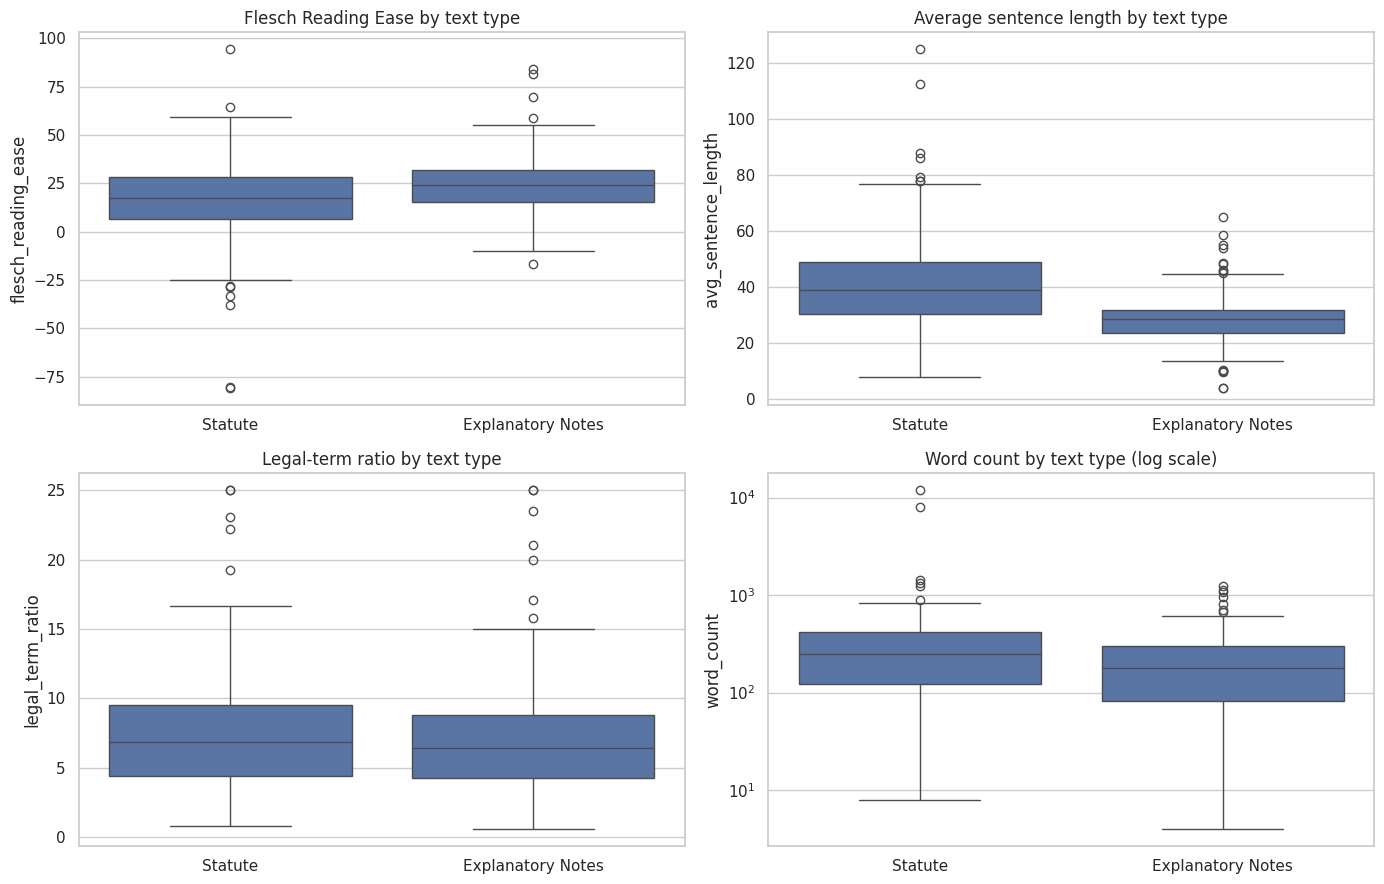

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.boxplot(data=doc_df, x="text_type", y="flesch_reading_ease", ax=axes[0, 0])
axes[0, 0].set_title("Flesch Reading Ease by text type")
axes[0, 0].set_xlabel("")

sns.boxplot(data=doc_df, x="text_type", y="avg_sentence_length", ax=axes[0, 1])
axes[0, 1].set_title("Average sentence length by text type")
axes[0, 1].set_xlabel("")

sns.boxplot(data=doc_df, x="text_type", y="legal_term_ratio", ax=axes[1, 0])
axes[1, 0].set_title("Legal-term ratio by text type")
axes[1, 0].set_xlabel("")

sns.boxplot(data=doc_df, x="text_type", y="word_count", ax=axes[1, 1])
axes[1, 1].set_yscale("log")
axes[1, 1].set_title("Word count by text type (log scale)")
axes[1, 1].set_xlabel("")

plt.tight_layout()
plt.show()


## 5. 연구의 전체 분석 절차

자료를 수집한 뒤 품질을 확인하고, 동일한 기준으로 특징을 산출한 후 기술통계·시각화·가설검정·머신러닝 분석을 수행한다.


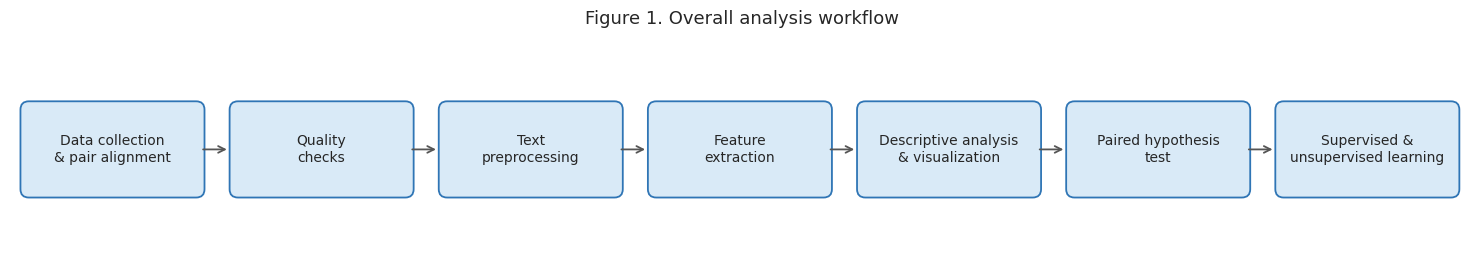

In [ ]:
from matplotlib.patches import FancyBboxPatch

workflow_steps = [
    "Data collection\n& pair alignment",
    "Quality\nchecks",
    "Text\npreprocessing",
    "Feature\nextraction",
    "Descriptive analysis\n& visualization",
    "Paired hypothesis\ntest",
    "Supervised &\nunsupervised learning",
]

fig, ax = plt.subplots(figsize=(15, 2.8))
ax.set_xlim(0, len(workflow_steps))
ax.set_ylim(0, 1)
ax.axis("off")

for i, step in enumerate(workflow_steps):
    box = FancyBboxPatch(
        (i + 0.08, 0.3), 0.82, 0.4,
        boxstyle="round,pad=0.03,rounding_size=0.04",
        facecolor="#D9EAF7", edgecolor="#2F75B5", linewidth=1.3,
    )
    ax.add_patch(box)
    ax.text(i + 0.49, 0.5, step, ha="center", va="center", fontsize=10)
    if i < len(workflow_steps) - 1:
        ax.annotate(
            "", xy=(i + 1.05, 0.5), xytext=(i + 0.91, 0.5),
            arrowprops=dict(arrowstyle="->", color="#555555", linewidth=1.3),
        )

plt.title("Figure 1. Overall analysis workflow", fontsize=13, pad=15)
plt.tight_layout()
plt.savefig("figure1_analysis_workflow.png", dpi=300, bbox_inches="tight")
plt.show()


## 6. 기술통계와 전반적 비교

법률 조문과 Explanatory Notes의 평균 및 중앙값을 함께 비교한다. 법률 조문에는 실제 구조에서 발생한 매우 긴 section이 포함되므로 평균만으로 판단하지 않는다. 대응쌍별 변화량은 `Notes - Statute`로 계산한다.


In [ ]:
# 대응쌍 단위의 특징표 생성
pair_metrics = [
    "word_count", "avg_sentence_length", "avg_word_length",
    "lexical_diversity", "flesch_reading_ease", "legal_term_ratio",
    "modal_ratio", "condition_ratio", "cross_reference_ratio",
]

statute_metrics = (
    doc_df.loc[doc_df["label"] == 0, ["pair_id"] + pair_metrics]
    .rename(columns={metric: f"{metric}_statute" for metric in pair_metrics})
)
notes_metrics = (
    doc_df.loc[doc_df["label"] == 1, ["pair_id"] + pair_metrics]
    .rename(columns={metric: f"{metric}_notes" for metric in pair_metrics})
)

pair_df = (
    df_work[[
        "pair_id", "act_title", "section_number", "section_title",
        "statute_text_clean", "notes_text_clean", "statute_url", "notes_url",
    ]]
    .merge(statute_metrics, on="pair_id", how="left", validate="one_to_one")
    .merge(notes_metrics, on="pair_id", how="left", validate="one_to_one")
)

for metric in pair_metrics:
    pair_df[f"delta_{metric}"] = (
        pair_df[f"{metric}_notes"] - pair_df[f"{metric}_statute"]
    )

table4_metrics = [
    ("단어 수", "word_count"),
    ("평균 문장 길이", "avg_sentence_length"),
    ("평균 단어 길이", "avg_word_length"),
    ("Flesch Reading Ease", "flesch_reading_ease"),
]

table4_rows = []
for label, metric in table4_metrics:
    table4_rows.append({
        "지표": label,
        "법률 조문 평균": pair_df[f"{metric}_statute"].mean(),
        "법률 조문 중앙값": pair_df[f"{metric}_statute"].median(),
        "Notes 평균": pair_df[f"{metric}_notes"].mean(),
        "Notes 중앙값": pair_df[f"{metric}_notes"].median(),
    })

table4 = pd.DataFrame(table4_rows)
print("Table 4. 법률 조문과 Explanatory Notes의 주요 기술통계")
display(table4.round(2))

comparison_counts = pd.DataFrame({
    "비교 항목": ["Notes 단어 수 감소", "Notes 평균 문장 길이 감소", "Notes FRE 증가"],
    "대응쌍 수": [
        int((pair_df["delta_word_count"] < 0).sum()),
        int((pair_df["delta_avg_sentence_length"] < 0).sum()),
        int((pair_df["delta_flesch_reading_ease"] > 0).sum()),
    ],
    "전체": [len(pair_df)] * 3,
})
display(comparison_counts)

print(f"FRE 변화량 평균: {pair_df['delta_flesch_reading_ease'].mean():.2f}")
print(f"FRE 변화량 중앙값: {pair_df['delta_flesch_reading_ease'].median():.2f}")


Table 4. 법률 조문과 Explanatory Notes의 주요 기술통계


,지표,법률 조문 평균,법률 조문 중앙값,Notes 평균,Notes 중앙값
0,단어 수,431.35,247.00,227.42,178.50
1,평균 문장 길이,40.73,39.00,28.47,28.54
2,평균 단어 길이,5.03,4.96,5.21,5.13
3,Flesch Reading Ease,15.28,17.15,24.96,23.86


,비교 항목,대응쌍 수,전체
0,Notes 단어 수 감소,98,150
1,Notes 평균 문장 길이 감소,117,150
2,Notes FRE 증가,108,150


FRE 변화량 평균: 9.67
FRE 변화량 중앙값: 7.31


## 7. 논문 수록 시각화

그림 2는 대응쌍별 FRE 변화량의 분포를, 그림 3은 동일 대응쌍의 법률 조문과 Notes FRE를 직접 비교한다. 변화량이 0보다 크거나 산점도의 점이 대각선 위에 있으면 Notes의 점수가 더 높다.


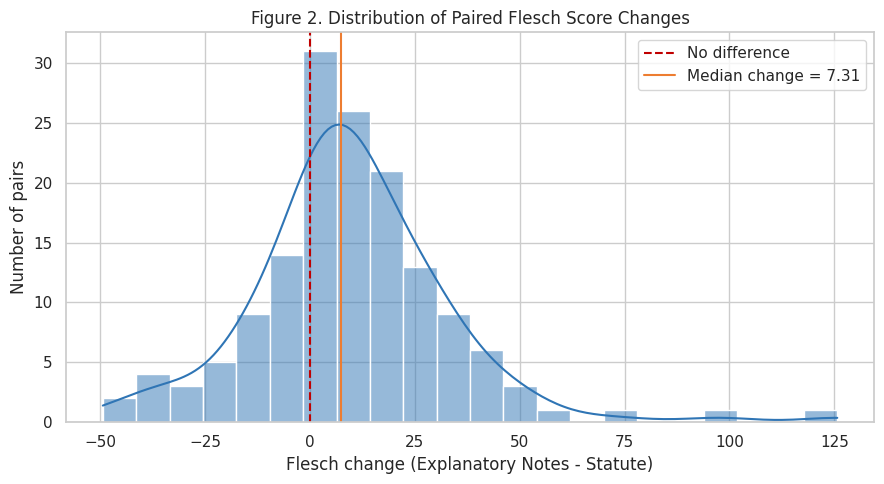

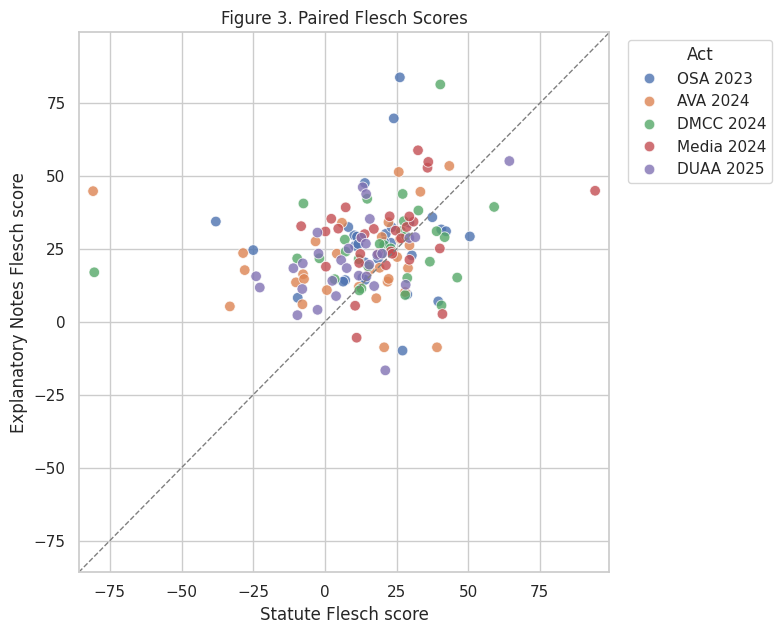

In [ ]:
# Figure 2. 대응쌍별 FRE 변화량
plt.figure(figsize=(9, 5))
sns.histplot(
    data=pair_df,
    x="delta_flesch_reading_ease",
    bins=22,
    kde=True,
    color="#2F75B5",
)
plt.axvline(0, color="#C00000", linestyle="--", linewidth=1.5, label="No difference")
plt.axvline(
    pair_df["delta_flesch_reading_ease"].median(),
    color="#ED7D31", linewidth=1.5,
    label=f"Median change = {pair_df['delta_flesch_reading_ease'].median():.2f}",
)
plt.title("Figure 2. Distribution of Paired Flesch Score Changes")
plt.xlabel("Flesch change (Explanatory Notes - Statute)")
plt.ylabel("Number of pairs")
plt.legend()
plt.tight_layout()
plt.savefig("figure2_fre_change_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

# Figure 3. 대응 FRE 점수 산점도
act_labels = {
    "Online Safety Act 2023": "OSA 2023",
    "Automated Vehicles Act 2024": "AVA 2024",
    "Digital Markets, Competition and Consumers Act 2024": "DMCC 2024",
    "Media Act 2024": "Media 2024",
    "Data (Use and Access) Act 2025": "DUAA 2025",
}
pair_df["act_label"] = pair_df["act_title"].map(act_labels)

plt.figure(figsize=(8, 6.5))
sns.scatterplot(
    data=pair_df,
    x="flesch_reading_ease_statute",
    y="flesch_reading_ease_notes",
    hue="act_label",
    s=58,
    alpha=0.8,
    palette="deep",
)
axis_min = min(
    pair_df["flesch_reading_ease_statute"].min(),
    pair_df["flesch_reading_ease_notes"].min(),
) - 5
axis_max = max(
    pair_df["flesch_reading_ease_statute"].max(),
    pair_df["flesch_reading_ease_notes"].max(),
) + 5
plt.plot([axis_min, axis_max], [axis_min, axis_max], "--", color="gray", linewidth=1)
plt.xlim(axis_min, axis_max)
plt.ylim(axis_min, axis_max)
plt.title("Figure 3. Paired Flesch Scores")
plt.xlabel("Statute Flesch score")
plt.ylabel("Explanatory Notes Flesch score")
plt.legend(title="Act", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("figure3_paired_fre_scatter.png", dpi=300, bbox_inches="tight")
plt.show()


## 8. 대응표본 통계적 가설검정

첫 번째 연구 질문에 답하기 위해 대응쌍별 FRE 차이를 검정한다.

- **귀무가설(H0):** Explanatory Notes의 FRE가 법률 조문보다 체계적으로 높지 않다.
- **대립가설(H1):** Explanatory Notes의 FRE가 법률 조문보다 높다.
- **유의수준:** `α=.05`

먼저 Shapiro-Wilk 검정으로 차이값의 정규성을 확인한다. 정규성 가정이 충족되지 않으므로 단측 Wilcoxon 부호순위 검정을 적용하며, 순위양분상관을 효과크기로 보고한다.


In [ ]:
alpha = 0.05
paired_difference = pair_df["delta_flesch_reading_ease"].dropna()

shapiro_result = stats.shapiro(paired_difference)
wilcoxon_result = stats.wilcoxon(
    pair_df["flesch_reading_ease_notes"],
    pair_df["flesch_reading_ease_statute"],
    alternative="greater",
    zero_method="wilcox",
    method="auto",
)

nonzero_difference = paired_difference[paired_difference != 0]
ranks = stats.rankdata(np.abs(nonzero_difference))
positive_rank_sum = ranks[nonzero_difference.to_numpy() > 0].sum()
negative_rank_sum = ranks[nonzero_difference.to_numpy() < 0].sum()
rank_biserial = (
    (positive_rank_sum - negative_rank_sum)
    / (positive_rank_sum + negative_rank_sum)
)

test_results = pd.DataFrame([
    {
        "검정": "Shapiro-Wilk",
        "통계량": shapiro_result.statistic,
        "p값": shapiro_result.pvalue,
        "해석": "정규성 가정 불충족" if shapiro_result.pvalue < alpha else "정규성 기각 안 됨",
    },
    {
        "검정": "Wilcoxon signed-rank (Notes > Statute)",
        "통계량": wilcoxon_result.statistic,
        "p값": wilcoxon_result.pvalue,
        "해석": "귀무가설 기각" if wilcoxon_result.pvalue < alpha else "귀무가설 기각 못함",
    },
])
display(test_results)
print(f"Rank-biserial correlation = {rank_biserial:.3f}")
print(f"Notes FRE가 더 높은 대응쌍 = {(paired_difference > 0).sum()} / {len(paired_difference)}")


,검정,통계량,p값,해석
0,Shapiro-Wilk,0.933184,1.664777e-06,정규성 가정 불충족
1,Wilcoxon signed-rank (Notes > Statute),8434.000000,9.964549e-08,귀무가설 기각


Rank-biserial correlation = 0.489
Notes FRE가 더 높은 대응쌍 = 108 / 150


## 9. 법률별 단순화 정도 비교

각 법률의 FRE 변화량 중앙값과 Notes의 FRE가 더 높은 대응쌍 수를 비교한다. 법률별 표본은 각각 30개이며 확률표본이 아니므로, 법률 간 차이는 선정된 자료 안에서만 해석한다.


In [ ]:
table5 = (
    pair_df.groupby("act_title")
    .agg(
        대응쌍수=("pair_id", "count"),
        FRE_변화량_중앙값=("delta_flesch_reading_ease", "median"),
        Notes_FRE_증가_대응쌍=(
            "delta_flesch_reading_ease",
            lambda values: int((values > 0).sum()),
        ),
    )
    .reset_index()
    .rename(columns={"act_title": "법률명"})
)

print("Table 5. 법률별 FRE 변화량")
display(table5.round(2))


Table 5. 법률별 FRE 변화량


,법률명,대응쌍수,FRE_변화량_중앙값,Notes_FRE_증가_대응쌍
0,Automated Vehicles Act 2024,30,10.13,20
1,Data (Use and Access) Act 2025,30,11.67,24
2,"Digital Markets, Competition and Consumers Act 2024",30,5.04,20
3,Media Act 2024,30,7.46,22
4,Online Safety Act 2023,30,7.00,22


## 10. 지도학습: 법률 조문과 Explanatory Notes 분류

### 분석 설계

- **문제 유형:** 이항 분류
- **입력 X:** 9개의 언어적 특징
- **정답 y:** `Statute=0`, `Explanatory Notes=1`
- **모델:** 로지스틱 회귀
- **평가:** Accuracy, Precision, Recall, F1-score, Confusion Matrix

`pair_id`, 법률명, URL, section 번호처럼 정답을 간접적으로 드러낼 수 있는 식별자는 입력 특징에서 제외한다. 또한 같은 대응쌍의 Statute와 Notes가 학습용과 테스트용에 나뉘는 정보 누출을 방지하기 위해 `pair_id`를 그룹으로 설정해 80:20으로 분할한다.

단어 수와 평균 문장 길이는 극단값의 영향을 줄이기 위해 로그 변환한다. 실제 행은 삭제하지 않는다.


In [ ]:
supervised_features = [
    "log_word_count",
    "log_avg_sentence_length",
    "avg_word_length",
    "lexical_diversity",
    "flesch_reading_ease",
    "legal_term_ratio",
    "modal_ratio",
    "condition_ratio",
    "cross_reference_ratio",
]

X = doc_df[supervised_features]
y = doc_df["label"]
groups = doc_df["pair_id"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE,
)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("학습 데이터:", X_train.shape)
print("테스트 데이터:", X_test.shape)
print("\n테스트 데이터 레이블 분포")
print(y_test.value_counts().sort_index().rename(index={0: "Statute", 1: "Notes"}))

train_pairs = set(doc_df.iloc[train_idx]["pair_id"])
test_pairs = set(doc_df.iloc[test_idx]["pair_id"])
print("\n학습·테스트 pair_id 중복:", len(train_pairs & test_pairs))


학습 데이터: (240, 9)
테스트 데이터: (60, 9)

테스트 데이터 레이블 분포
label
Statute    30
Notes      30
Name: count, dtype: int64

학습·테스트 pair_id 중복: 0


In [ ]:
# 1) 단순 기준선 모델
baseline_model = DummyClassifier(strategy="most_frequent")
baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)

# 2) 표준화 + 로지스틱 회귀
supervised_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE,
    )),
])

supervised_model.fit(X_train, y_train)
y_pred = supervised_model.predict(X_test)

model_scores = pd.DataFrame({
    "Model": ["Most-frequent baseline", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, baseline_pred),
        accuracy_score(y_test, y_pred),
    ],
    "F1 (Notes)": [
        f1_score(y_test, baseline_pred, zero_division=0),
        f1_score(y_test, y_pred),
    ],
})

display(model_scores.round(3))


,Model,Accuracy,F1 (Notes)
0,Most-frequent baseline,0.500,0.0
1,Logistic Regression,0.783,0.8


Table 6. 로지스틱 회귀 분류 결과


,구분,정확도,정밀도,재현율,F1 점수
0,Statute,NaN,0.840,0.700,0.764
1,Explanatory Notes,NaN,0.743,0.867,0.800
2,전체 모형,0.783,NaN,NaN,NaN


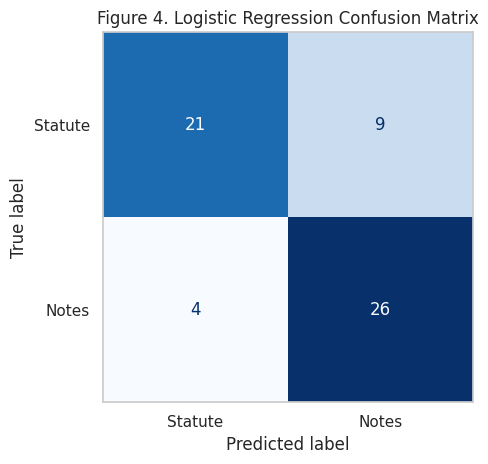

In [ ]:
classification_metrics = pd.DataFrame(
    classification_report(
        y_test,
        y_pred,
        target_names=["Statute", "Explanatory Notes"],
        output_dict=True,
        zero_division=0,
    )
).T

table6 = pd.DataFrame([
    {
        "구분": "Statute",
        "정확도": np.nan,
        "정밀도": classification_metrics.loc["Statute", "precision"],
        "재현율": classification_metrics.loc["Statute", "recall"],
        "F1 점수": classification_metrics.loc["Statute", "f1-score"],
    },
    {
        "구분": "Explanatory Notes",
        "정확도": np.nan,
        "정밀도": classification_metrics.loc["Explanatory Notes", "precision"],
        "재현율": classification_metrics.loc["Explanatory Notes", "recall"],
        "F1 점수": classification_metrics.loc["Explanatory Notes", "f1-score"],
    },
    {
        "구분": "전체 모형",
        "정확도": accuracy_score(y_test, y_pred),
        "정밀도": np.nan,
        "재현율": np.nan,
        "F1 점수": np.nan,
    },
])

print("Table 6. 로지스틱 회귀 분류 결과")
display(table6.round(3))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Statute", "Notes"],
    cmap="Blues",
    colorbar=False,
)
plt.title("Figure 4. Logistic Regression Confusion Matrix")
plt.grid(False)
plt.tight_layout()
plt.savefig("figure4_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


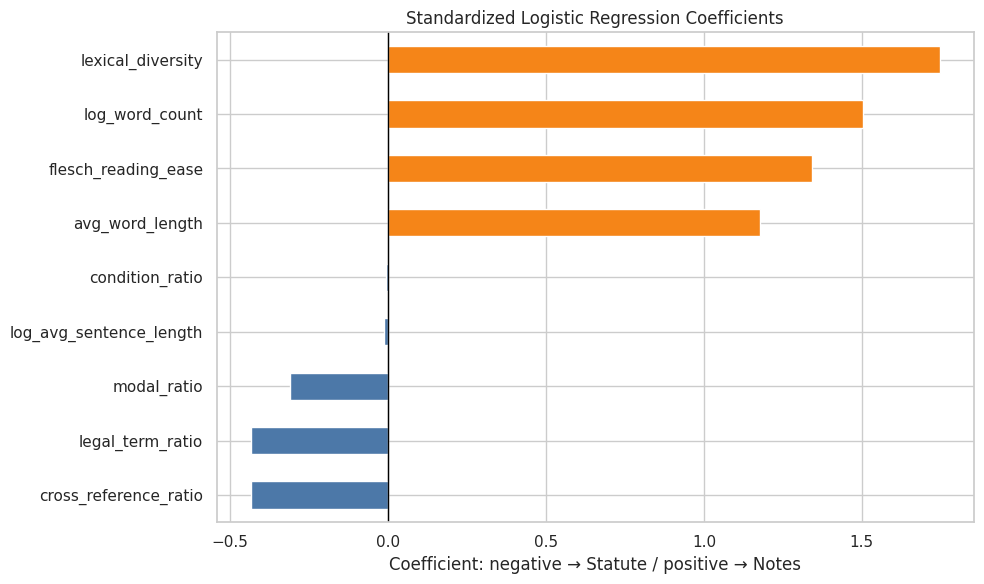

,coefficient
cross_reference_ratio,-0.434
legal_term_ratio,-0.434
modal_ratio,-0.309
log_avg_sentence_length,-0.013
condition_ratio,-0.006
avg_word_length,1.179
flesch_reading_ease,1.343
log_word_count,1.504
lexical_diversity,1.746


In [ ]:
# 표준화된 특징의 계수: 양수는 Notes(1), 음수는 Statute(0) 예측 방향
coefficients = pd.Series(
    supervised_model.named_steps["classifier"].coef_[0],
    index=supervised_features,
    name="coefficient",
).sort_values()

plt.figure(figsize=(10, 6))
colors = ["#4C78A8" if value < 0 else "#F58518" for value in coefficients]
coefficients.plot(kind="barh", color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.title("Standardized Logistic Regression Coefficients")
plt.xlabel("Coefficient: negative → Statute / positive → Notes")
plt.tight_layout()
plt.show()

display(coefficients.to_frame().round(3))


### 지도학습 결과 해석

- 기준선 정확도는 **0.500**, 로지스틱 회귀 정확도는 **0.783**으로 나타났다.
- Explanatory Notes 클래스의 F1-score는 **0.800**이었다.
- 테스트 문서 60개 중 Statute 21개, Notes 26개를 정확하게 분류하여 총 47개를 맞혔다.
- 이는 일반적인 언어 특징만으로도 두 문서 유형에 체계적인 차이가 있음을 보여준다.
- 다만 높은 분류 성능 자체가 Notes의 단순화 성공을 증명하는 것은 아니다. 모델 계수는 다른 특징을 통제했을 때의 분류 방향이며 인과효과로 해석하지 않는다.


## 11. 비지도학습: 단순화 양상 군집화

지도학습에서는 개별 문서의 유형을 예측했다. 비지도학습에서는 150개 대응쌍을 다시 분석 단위로 사용하고, 다음 차이값을 생성한다.

\[
\Delta = \text{Explanatory Notes의 값} - \text{Statute의 값}
\]

- `delta_flesch_reading_ease`가 양수이면 Notes의 가독성 점수가 더 높다.
- `delta_avg_sentence_length`가 음수이면 Notes의 문장이 더 짧다.
- `delta_legal_term_ratio`가 음수이면 Notes의 법률용어 비율이 더 낮다.
- `delta_cross_reference_ratio`가 음수이면 Notes의 상호참조 비율이 더 낮다.

K-means는 거리 기반 모델이므로 극단값이 군집 전체를 지배하지 않도록 부호를 보존한 로그 변환과 `RobustScaler`를 적용한다. **원본 관측치는 삭제하거나 변경하지 않는다.**


In [ ]:
cluster_features = [
    "delta_flesch_reading_ease",
    "delta_avg_sentence_length",
    "delta_avg_word_length",
    "delta_legal_term_ratio",
    "delta_cross_reference_ratio",
]

cluster_input = pair_df[cluster_features].copy()

# 부호를 유지하면서 극단적 크기만 완화: sign(x) × log(1 + |x|)
cluster_transformed = (
    np.sign(cluster_input) * np.log1p(np.abs(cluster_input))
)

cluster_scaler = RobustScaler()
X_cluster = cluster_scaler.fit_transform(cluster_transformed)

print("군집화 입력 크기:", X_cluster.shape)
print("군집화 입력 결측치:", int(np.isnan(X_cluster).sum()))


군집화 입력 크기: (150, 5)
군집화 입력 결측치: 0


,k,inertia,silhouette
0,2,287.053,0.404
1,3,230.342,0.348
2,4,191.940,0.244
3,5,164.892,0.245
4,6,144.350,0.263


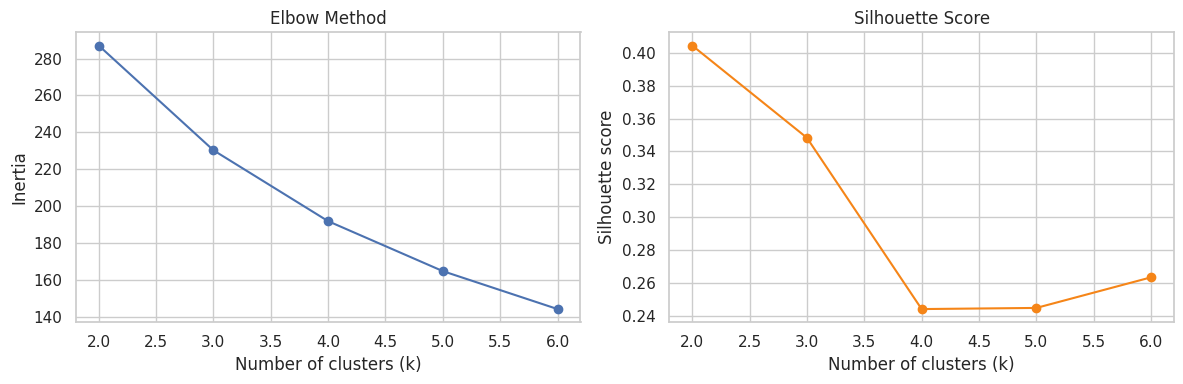

선택된 군집 수: 2


In [ ]:
# k=2~6을 비교하고 실루엣 점수가 가장 높은 k를 선택
k_results = []

for k in range(2, 7):
    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20,
    )
    labels = model.fit_predict(X_cluster)

    k_results.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(X_cluster, labels),
    })

k_scores = pd.DataFrame(k_results)
display(k_scores.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_scores["k"], k_scores["inertia"], marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(k_scores["k"], k_scores["silhouette"], marker="o", color="#F58518")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")

plt.tight_layout()
plt.show()

best_k = int(k_scores.loc[k_scores["silhouette"].idxmax(), "k"])
print("선택된 군집 수:", best_k)


In [ ]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=20,
)
pair_df["cluster"] = kmeans.fit_predict(X_cluster)

cluster_summary = pair_df.groupby("cluster")[cluster_features].agg(["count", "median", "mean"])
display(cluster_summary.round(3))

cluster_medians = pair_df.groupby("cluster")[cluster_features].median()

# K-means 번호 자체에는 의미가 없으므로 FRE 개선 중앙값을 기준으로 설명용 이름 부여
if best_k == 2:
    improvement_cluster = cluster_medians["delta_flesch_reading_ease"].idxmax()
    limited_cluster = cluster_medians["delta_flesch_reading_ease"].idxmin()
    profile_map = {
        improvement_cluster: "가독성 개선형",
        limited_cluster: "제한적·실패형",
    }
else:
    profile_map = {cluster: f"Exploratory cluster {cluster}" for cluster in cluster_medians.index}

pair_df["cluster_profile"] = pair_df["cluster"].map(profile_map)

print("군집별 표본 수")
print(pair_df["cluster_profile"].value_counts())

print("\n군집별 차이값 중앙값")
display(
    pair_df.groupby("cluster_profile")[cluster_features]
    .median()
    .round(2)
)


table7 = (
    pair_df.groupby("cluster_profile")
    .agg(
        대응쌍수=("pair_id", "count"),
        FRE_변화량_중앙값=("delta_flesch_reading_ease", "median"),
        평균문장길이_변화량_중앙값=("delta_avg_sentence_length", "median"),
        법률용어비율_변화량_중앙값=("delta_legal_term_ratio", "median"),
        상호참조비율_변화량_중앙값=("delta_cross_reference_ratio", "median"),
    )
    .reset_index()
    .rename(columns={"cluster_profile": "군집"})
)
print("Table 7. K-means 군집별 단순화 특징")
display(table7.round(2))


delta_flesch_reading_ease                 delta_avg_sentence_length  \
                            count  median    mean                     count   
cluster                                                                       
0                             115  11.476  15.137                       115   
1                              35  -8.214  -8.273                        35   

                       delta_avg_word_length                \
        median    mean                 count median   mean   
cluster                                                      
0        -15.5 -19.198                   115  0.235  0.247   
1          6.0  10.557                    35  0.088 -0.052   

        delta_legal_term_ratio               delta_cross_reference_ratio  \
                         count median   mean                       count   
cluster                                                                    
0                          115  0.029  0.287                         115   
1                           35 -1.786 -2.621                          35   

                       
        median   mean  
cluster                
0        0.637  1.041  
1       -2.428 -1.975

군집별 표본 수
cluster_profile
가독성 개선형    115
제한적·실패형     35
Name: count, dtype: int64

군집별 차이값 중앙값


,delta_flesch_reading_ease,delta_avg_sentence_length,delta_avg_word_length,delta_legal_term_ratio,delta_cross_reference_ratio
cluster_profile,,,,,
가독성 개선형,11.48,-15.5,0.23,0.03,0.64
제한적·실패형,-8.21,6.0,0.09,-1.79,-2.43


Table 7. K-means 군집별 단순화 특징


,군집,대응쌍수,FRE_변화량_중앙값,평균문장길이_변화량_중앙값,법률용어비율_변화량_중앙값,상호참조비율_변화량_중앙값
0,가독성 개선형,115,11.48,-15.5,0.03,0.64
1,제한적·실패형,35,-8.21,6.0,-1.79,-2.43


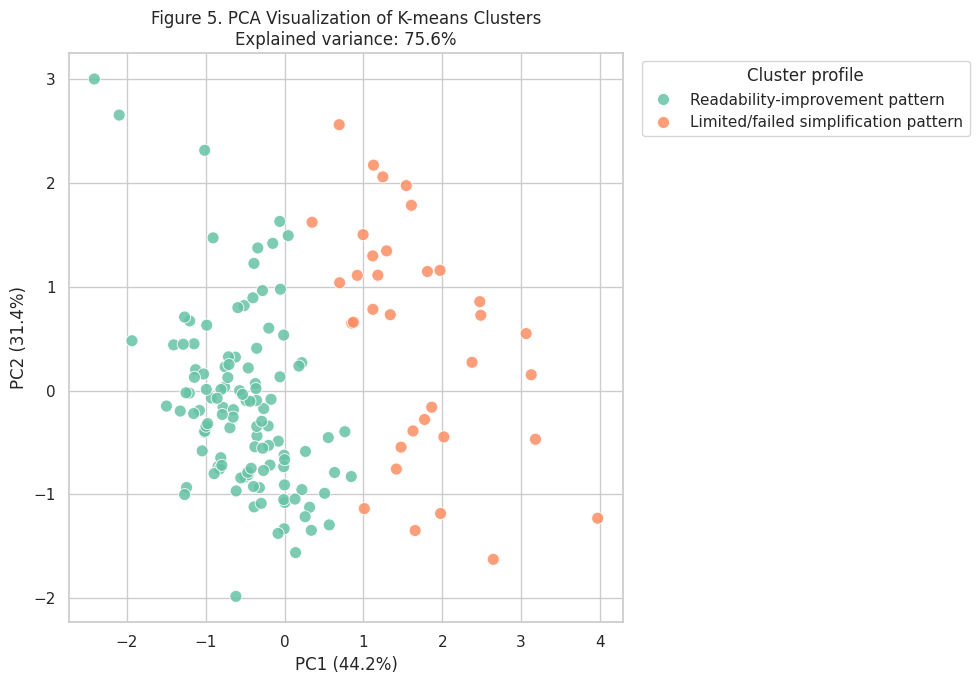

In [ ]:
pca = PCA(n_components=2)
pca_coordinates = pca.fit_transform(X_cluster)

pair_df["PC1"] = pca_coordinates[:, 0]
pair_df["PC2"] = pca_coordinates[:, 1]

cluster_plot_map = {
    "가독성 개선형": "Readability-improvement pattern",
    "제한적·실패형": "Limited/failed simplification pattern",
}
pair_df["cluster_profile_plot"] = pair_df["cluster_profile"].map(cluster_plot_map)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pair_df,
    x="PC1",
    y="PC2",
    hue="cluster_profile_plot",
    palette="Set2",
    s=75,
    alpha=0.85,
)
plt.title(
    "Figure 5. PCA Visualization of K-means Clusters\n"
    f"Explained variance: {pca.explained_variance_ratio_.sum():.1%}"
)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.legend(title="Cluster profile", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("figure5_kmeans_pca.png", dpi=300, bbox_inches="tight")
plt.show()


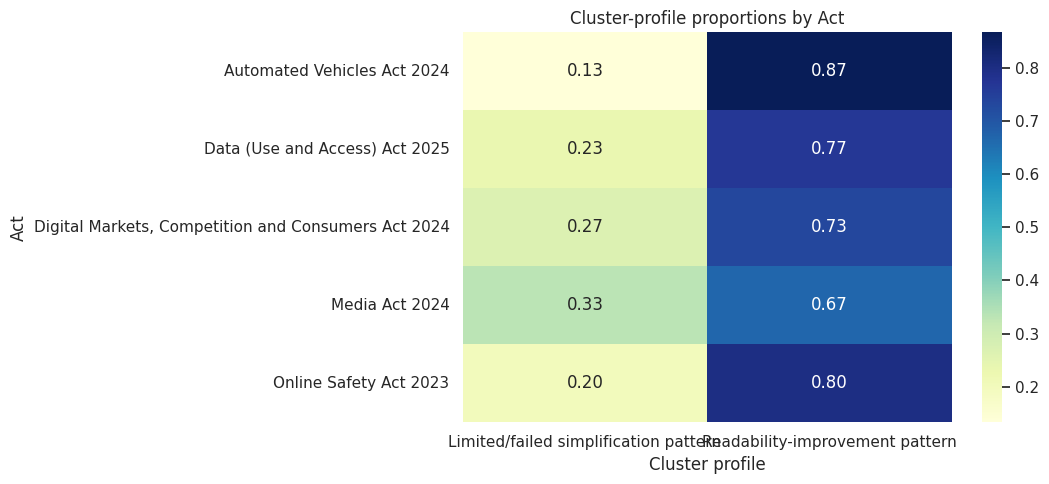

cluster_profile_plot,Limited/failed simplification pattern,Readability-improvement pattern
act_title,,
Automated Vehicles Act 2024,4,26
Data (Use and Access) Act 2025,7,23
"Digital Markets, Competition and Consumers Act 2024",8,22
Media Act 2024,10,20
Online Safety Act 2023,6,24


In [ ]:
# 법률별 군집 구성: 군집화에는 법률명을 사용하지 않았고 결과 해석에만 사용
act_cluster_ratio = pd.crosstab(
    pair_df["act_title"],
    pair_df["cluster_profile_plot"],
    normalize="index",
)

plt.figure(figsize=(11, 5))
sns.heatmap(act_cluster_ratio, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Cluster-profile proportions by Act")
plt.xlabel("Cluster profile")
plt.ylabel("Act")
plt.tight_layout()
plt.show()

display(pd.crosstab(pair_df["act_title"], pair_df["cluster_profile_plot"]))


In [ ]:
# 각 군집 중심에 가까운 대표 대응쌍 3개
centroid_distance = np.linalg.norm(
    X_cluster - kmeans.cluster_centers_[pair_df["cluster"].to_numpy()],
    axis=1,
)
pair_df["distance_to_centroid"] = centroid_distance

representative_cases = (
    pair_df.sort_values("distance_to_centroid")
    .groupby("cluster_profile", group_keys=False)
    .head(3)
)

display(
    representative_cases[[
        "cluster_profile", "act_title", "section_number", "section_title",
        "delta_flesch_reading_ease", "delta_avg_sentence_length",
        "delta_legal_term_ratio", "delta_cross_reference_ratio"
    ]].round(2)
)


,cluster_profile,act_title,section_number,section_title,delta_flesch_reading_ease,delta_avg_sentence_length,delta_legal_term_ratio,delta_cross_reference_ratio
127,가독성 개선형,Data (Use and Access) Act 2025,41,Power to remove person from the DVS register,4.02,-8.00,0.03,0.60
97,가독성 개선형,Media Act 2024,18,Power to require information,6.62,-9.34,0.09,1.00
73,가독성 개선형,"Digital Markets, Competition and Consumers Act 2024",154,CMA directions to other enforcers,4.52,-7.42,0.61,0.21
42,제한적·실패형,Automated Vehicles Act 2024,47,User-in-charge not liable for manner of driving,-10.53,10.25,-4.86,-2.43
83,제한적·실패형,"Digital Markets, Competition and Consumers Act 2024",279,Other consequential amendments,3.30,4.71,-1.00,-2.67
26,제한적·실패형,Online Safety Act 2023,212,Repeals: Digital Economy Act 2017,-21.29,22.33,-0.37,-4.20


In [ ]:
# 가독성 점수가 가장 크게 낮아진 사례: 후속 질적 분석 후보
failure_candidates = pair_df.nsmallest(10, "delta_flesch_reading_ease")

display(
    failure_candidates[[
        "pair_id", "act_title", "section_number", "section_title",
        "cluster_profile", "delta_flesch_reading_ease",
        "delta_avg_sentence_length", "delta_legal_term_ratio",
        "statute_url", "notes_url"
    ]].round(2)
)


,pair_id,act_title,section_number,section_title,cluster_profile,delta_flesch_reading_ease,delta_avg_sentence_length,delta_legal_term_ratio,statute_url,notes_url
119,MA2024_030,Media Act 2024,56,Short title,제한적·실패형,-49.33,6.00,-8.89,https://www.legislation.gov.uk/ukpga/2024/15/section/56/enacted,https://www.legislation.gov.uk/ukpga/2024/15/notes/division/6/index.htm
35,AVA2024_006,Automated Vehicles Act 2024,21,Enforcement by court,가독성 개선형,-47.85,-40.00,11.36,https://www.legislation.gov.uk/ukpga/2024/10/section/21/enacted,https://www.legislation.gov.uk/ukpga/2024/10/notes/division/6/index.htm
117,MA2024_028,Media Act 2024,53,Financial provisions,가독성 개선형,-38.32,-6.00,1.67,https://www.legislation.gov.uk/ukpga/2024/15/section/53/enacted,https://www.legislation.gov.uk/ukpga/2024/15/notes/division/6/index.htm
149,DUAA2025_030,Data (Use and Access) Act 2025,143,"Transitional, transitory and saving provision",제한적·실패형,-37.72,45.50,-12.31,https://www.legislation.gov.uk/ukpga/2025/18/section/143/enacted,https://www.legislation.gov.uk/ukpga/2025/18/notes/division/13/index.htm
25,OSA2023_026,Online Safety Act 2023,204,Extra-territorial application,제한적·실패형,-36.95,11.75,-1.18,https://www.legislation.gov.uk/ukpga/2023/50/section/204/enacted,https://www.legislation.gov.uk/ukpga/2023/50/notes/division/6/index.htm
62,DMCCA2024_003,"Digital Markets, Competition and Consumers Act 2024",30,Notice of findings,제한적·실패형,-35.04,18.60,0.34,https://www.legislation.gov.uk/ukpga/2024/13/section/30/enacted,https://www.legislation.gov.uk/ukpga/2024/13/notes/division/6/index.htm
28,OSA2023_029,Online Safety Act 2023,230,"""Age verification"" and ""age estimation""",제한적·실패형,-32.54,27.88,1.22,https://www.legislation.gov.uk/ukpga/2023/50/section/230/enacted,https://www.legislation.gov.uk/ukpga/2023/50/notes/division/6/index.htm
65,DMCCA2024_006,"Digital Markets, Competition and Consumers Act 2024",65,Authorisation for one person to act for another,제한적·실패형,-30.99,12.50,4.73,https://www.legislation.gov.uk/ukpga/2024/13/section/65/enacted,https://www.legislation.gov.uk/ukpga/2024/13/notes/division/6/index.htm
58,AVA2024_029,Automated Vehicles Act 2024,95,Disclosure and information: interaction with external constraints,가독성 개선형,-29.41,-25.86,17.34,https://www.legislation.gov.uk/ukpga/2024/10/section/95/enacted,https://www.legislation.gov.uk/ukpga/2024/10/notes/division/6/index.htm
26,OSA2023_027,Online Safety Act 2023,212,Repeals: Digital Economy Act 2017,제한적·실패형,-21.29,22.33,-0.37,https://www.legislation.gov.uk/ukpga/2023/50/section/212/enacted,https://www.legislation.gov.uk/ukpga/2023/50/notes/division/6/index.htm


### 비지도학습 결과 해석

- `k=2`의 실루엣 점수가 약 **0.404**로 가장 높아 두 개의 군집을 선택하였다.
- **가독성 개선형**에는 115쌍이 포함되었다. 이 군집에서 Notes의 FRE는 Statute보다 중앙값 기준 약 **11.48점 높고**, 평균 문장 길이는 약 **15.50단어 짧았다**.
- **제한적·실패형**에는 35쌍이 포함되었다. 이 군집에서는 Notes의 FRE가 중앙값 기준 약 **8.21점 낮고**, 평균 문장 길이는 약 **6.00단어 길었다**.
- 군집 이름은 관찰된 언어 특징을 요약하기 위한 탐색적 명칭이다. 두 번째 군집을 의미적 또는 법적 실패가 확정된 자료로 해석하지 않는다.


## 12. 지도학습과 비지도학습 결과 비교


In [ ]:
comparison_table = pd.DataFrame([
    {
        "구분": "지도학습",
        "모델": "Logistic Regression",
        "입력 단위": "300개 개별 문서",
        "정답 레이블": "Statute / Notes",
        "목적": "새로운 문서의 유형 예측",
        "평가": "Accuracy 0.783, Notes F1 0.800",
        "핵심 의미": "두 텍스트 유형의 언어 특징이 체계적으로 다름",
    },
    {
        "구분": "비지도학습",
        "모델": "K-means",
        "입력 단위": "150개 대응쌍의 차이값",
        "정답 레이블": "없음",
        "목적": "단순화 양상의 숨은 구조 탐색",
        "평가": "k=2, Silhouette 0.404",
        "핵심 의미": "가독성 개선형과 제한적·실패형 패턴이 구분됨",
    },
])

display(comparison_table)


,구분,모델,입력 단위,정답 레이블,목적,평가,핵심 의미
0,지도학습,Logistic Regression,300개 개별 문서,Statute / Notes,새로운 문서의 유형 예측,"Accuracy 0.783, Notes F1 0.800",두 텍스트 유형의 언어 특징이 체계적으로 다름
1,비지도학습,K-means,150개 대응쌍의 차이값,없음,단순화 양상의 숨은 구조 탐색,"k=2, Silhouette 0.404",가독성 개선형과 제한적·실패형 패턴이 구분됨


## 13. 단순화가 제한된 대표 사례

FRE 감소 폭과 평균 문장 길이 증가가 큰 대응쌍을 먼저 추출한 뒤, 법률 조문과 Notes 원문을 직접 읽어 정보 압축, 추가 설명, 조건·예외 및 상호참조 유지 여부를 확인하였다. 아래 사례 설명은 자동 분류 결과가 아니라 수치에 근거해 후보를 선정한 후 수행한 질적 검토 결과이다.


In [ ]:
case_notes = pd.DataFrame([
    {
        "act_title": "Data (Use and Access) Act 2025",
        "section_number": 143,
        "주요 특징": "여러 규정과 별표 참조를 하나의 긴 문장으로 설명",
    },
    {
        "act_title": "Online Safety Act 2023",
        "section_number": 204,
        "주요 특징": "여러 적용 범위를 하나의 문장으로 압축",
    },
    {
        "act_title": "Digital Markets, Competition and Consumers Act 2024",
        "section_number": 30,
        "주요 특징": "조사 절차, 예외 및 다른 조항 참조를 함께 유지",
    },
    {
        "act_title": "Online Safety Act 2023",
        "section_number": 230,
        "주요 특징": "제3자 서비스와 적용 조항에 관한 추가 설명으로 문장 길이 증가",
    },
])

table8 = (
    pair_df.merge(
        case_notes,
        on=["act_title", "section_number"],
        how="inner",
        validate="one_to_one",
    )
    [[
        "act_title", "section_number", "section_title",
        "delta_flesch_reading_ease", "delta_avg_sentence_length", "주요 특징",
    ]]
    .rename(columns={
        "act_title": "법률명",
        "section_number": "조항",
        "section_title": "조항명",
        "delta_flesch_reading_ease": "FRE 변화량",
        "delta_avg_sentence_length": "평균 문장 길이 변화량",
    })
    .sort_values("FRE 변화량")
)

print("Table 8. Explanatory Notes의 단순화가 제한된 대표 사례")
display(table8.round(2))


Table 8. Explanatory Notes의 단순화가 제한된 대표 사례


,법률명,조항,조항명,FRE 변화량,평균 문장 길이 변화량,주요 특징
3,Data (Use and Access) Act 2025,143,"Transitional, transitory and saving provision",-37.72,45.50,여러 규정과 별표 참조를 하나의 긴 문장으로 설명
0,Online Safety Act 2023,204,Extra-territorial application,-36.95,11.75,여러 적용 범위를 하나의 문장으로 압축
2,"Digital Markets, Competition and Consumers Act 2024",30,Notice of findings,-35.04,18.60,"조사 절차, 예외 및 다른 조항 참조를 함께 유지"
1,Online Safety Act 2023,230,"""Age verification"" and ""age estimation""",-32.54,27.88,제3자 서비스와 적용 조항에 관한 추가 설명으로 문장 길이 증가


## 14. 논문 반영용 최종 결과 요약

### 데이터와 전처리

5개 영국 디지털 규제 법률에서 각각 30개씩 총 150개의 법률 조문-Explanatory Notes 대응쌍을 분석하였다. 데이터는 150행 21열이며, 필수 분석 열의 결측값과 중복 `pair_id`는 없었다. Chapter 관련 결측값은 법률 구조에서 발생한 것이므로 유지하였다. 극단적으로 긴 실제 조항은 삭제하지 않고 IQR 이상치 플래그와 로그 변환을 사용하였다.

### 기술통계와 가설검정

법률 조문의 평균 문장 길이는 40.73단어, Notes는 28.47단어였다. 평균 FRE는 법률 조문 15.28, Notes 24.96이었고, 150쌍 중 108쌍에서 Notes의 FRE가 더 높았다. 차이값은 정규성 가정을 충족하지 않았으며, 단측 Wilcoxon 부호순위 검정 결과 Notes의 FRE가 유의하게 높았다(`W=8434.0`, `p<.001`, `r_rb=.489`).

### 지도학습

같은 대응쌍이 학습 자료와 테스트 자료에 동시에 포함되지 않도록 `pair_id` 기준 그룹 분할을 적용하였다. 로지스틱 회귀의 정확도는 `.783`, Notes의 F1 점수는 `.800`이었다. 이는 두 문서 유형 사이에 반복되는 언어적 차이가 있음을 보여주지만, 분류 가능성이 곧 단순화 성공을 의미하지는 않는다.

### 비지도학습과 사례 검토

K-means 분석에서는 115쌍이 가독성 개선형, 35쌍이 제한적·실패형으로 구분되었다. 두 번째 군집에서는 Notes의 FRE가 중앙값 기준 8.21점 낮고 평균 문장 길이는 6.00단어 길었다. 대표 사례에서는 여러 내용을 한 문장으로 합치거나 배경·적용 범위를 추가하고 조건과 상호참조를 유지할 때 단순화 효과가 제한되는 양상이 확인되었다.

### 해석 범위

FRE는 표면적 언어 형식을 측정하는 간접 지표이며 실제 독자의 이해도나 법적 정확성을 직접 평가하지 않는다. 또한 표본은 5개 디지털 규제 법률에서 선정한 비확률 표본이므로 결과는 해당 범위 안에서 해석한다.


## 15. 분석 결과 파일 저장

다음 셀은 대응쌍별 파생변수와 군집 정보를 별도 CSV로 저장한다. 제출용 원본 CSV는 수정하지 않는다.


In [ ]:
RESULT_FILENAME = "final_legal_text_analysis_results.csv"
pair_df.to_csv(RESULT_FILENAME, index=False, encoding="utf-8-sig")

print(f"저장 완료: {RESULT_FILENAME}")
print("생성된 논문용 그림:")
for filename in [
    "figure1_analysis_workflow.png",
    "figure2_fre_change_histogram.png",
    "figure3_paired_fre_scatter.png",
    "figure4_confusion_matrix.png",
    "figure5_kmeans_pca.png",
]:
    print(" -", filename)


저장 완료: final_legal_text_analysis_results.csv
생성된 논문용 그림:
 - figure1_analysis_workflow.png
 - figure2_fre_change_histogram.png
 - figure3_paired_fre_scatter.png
 - figure4_confusion_matrix.png
 - figure5_kmeans_pca.png
